Checking the version of nvidia

In [ ]:
!nvidia-smi

Tue Feb 17 16:24:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Mount your drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -q /content/drive/MyDrive/Traffic_signs_dataset.zip -d /content/my_dataset


Ultralytics requires a particular folder structure to store training data for models. Ultralytics requires a particular folder structure to store training data for models. The root folder is named “data”. Inside, there are two main folders:

Train: These are the actual images used to train the model. In one epoch of training, every image in the train set is passed into the neural network. The training algorithm adjusts the network weights to fit the data in the images.

Validation: These images are used to check the model's performance at the end of each training epoch.

In each of these folders is a “images” folder and a “labels” folder, which hold the image files and annotation files respectively.

In [ ]:
!wget -O /content/train_val_split.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py
!python train_val_split.py --datapath="/content/my_dataset" --train_pct=0.8

--2026-02-07 11:32:08--  https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3203 (3.1K) [text/plain]
Saving to: ‘/content/train_val_split.py’

/content/train_val_ 100%[===================>]   3.13K  --.-KB/s    in 0s      

2026-02-07 11:32:09 (70.8 MB/s) - ‘/content/train_val_split.py’ saved [3203/3203]

Created folder at /content/data/train/images.
Created folder at /content/data/train/labels.
Created folder at /content/data/validation/images.
Created folder at /content/data/validation/labels.
Number of image files: 0
Number of annotation files: 0
Images moving to train: 0
Images moving to validation: 0


Next we will install ultralytics

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.8 MB/s eta 0:00:00


Now we will create a Yaml file for messy datasets. This is optional, if your dataset is splitted well then you should not run this code cell.

In [ ]:
# Python function to automatically create data.yaml config file
# 1. Reads "classes.txt" file to get list of class names
# 2. Creates data dictionary with correct paths to folders, number of classes, and names of classes
# 3. Writes data in YAML format to data.yaml

import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read class.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Create data dictionary
  data = {
      'path': '/content/data',
      'train': 'train/images',
      'val': 'validation/images',
      'nc': number_of_classes,
      'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Define path to classes.txt and run function
path_to_classes_txt = '/content/custom_data/classes.txt'
path_to_data_yaml = '/content/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat /content/data.yaml

Now that your dataset is properly organized and the configuration file is ready, you can begin training your model. Before starting, there are a few key parameters you’ll need to choose. For a more detailed explanation of these settings and guidance on selecting the right values, you can check my article on training YOLO models locally.

Model architecture and size (model)

YOLO11 offers multiple model sizes for training, including yolo11n.pt, yolo11s.pt, yolo11m.pt, yolo11l.pt, and yolo11x.pt.

Smaller models train and run faster, making them suitable for edge devices or real-time applications, but they may deliver lower accuracy.
Larger models generally provide better detection accuracy, though they require more computational resources and run more slowly.

If you’re unsure which model to start with, yolo11s.pt is often a good balance between speed and accuracy.

You can also train older YOLO versions such as YOLOv8 or YOLOv5 by replacing yolo11 with yolov8 or yolov5 in the model name.

Number of epochs (epochs)

In machine learning, an epoch represents one complete pass through the entire training dataset. The number of epochs determines how long the model will train.

The ideal value depends on factors such as dataset size and model complexity, but here are some practical starting points:

If your dataset contains fewer than 200 images, start with around 60 epochs.
If your dataset contains more than 200 images, start with around 40 epochs.

These values can be adjusted later based on training performance and validation results.

Image resolution (imgsz)

The input image resolution has a significant effect on both model speed and accuracy.

Lower resolutions improve inference speed and reduce computational requirements, but may decrease detection accuracy.
Higher resolutions can improve accuracy, especially for small objects, but require more processing power.

YOLO models are commonly trained and used at 640 × 640 resolution. However, if you need faster performance or expect to work with lower-quality images, you may want to experiment with smaller resolutions such as 480 × 480.

Run the following code block to begin training. If you want to use a different model, number of epochs, or resolution, change model, epochs, or imgsz.

In [ ]:
!yolo detect train data='/content/my_dataset/Traffic_signs_dataset/car/data.yaml' model=yolo11s.pt epochs=50 imgsz=640

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/my_dataset/Traffic_signs_dataset/car/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7,

Extracting the model from colab to my drive

In [ ]:
!cp -r /content/runs/detect/train /content/drive/MyDrive/yolo_models_3/


Testing the model against my cross validation set

In [ ]:
!yolo detect predict model=drive/MyDrive/yolo_models_3/weights/best.pt source='/content/my_dataset/Traffic_signs_dataset/car/valid/images' save=True

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,418,605 parameters, 0 gradients, 21.3 GFLOPs

image 1/801 /content/my_dataset/Traffic_signs_dataset/car/valid/images/000001_jpg.rf.5eb4f984823b1a44afc9bf98804daa50.jpg: 640x640 1 Speed Limit 30, 15.6ms
image 2/801 /content/my_dataset/Traffic_signs_dataset/car/valid/images/000002_jpg.rf.d65ebeef4d1cb26e3fc1a826770b729f.jpg: 640x640 1 Speed Limit 30, 15.6ms
image 3/801 /content/my_dataset/Traffic_signs_dataset/car/valid/images/000004_jpg.rf.00126fe7725236ec5dc849bac78543c2.jpg: 640x640 1 Speed Limit 30, 15.5ms
image 4/801 /content/my_dataset/Traffic_signs_dataset/

In [ ]:
!cp -r /content/runs/detect/predict /content/drive/MyDrive/Model_predict_1/


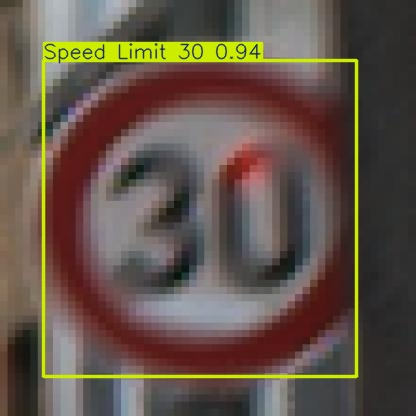

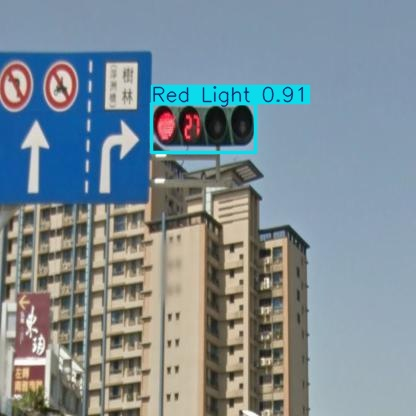

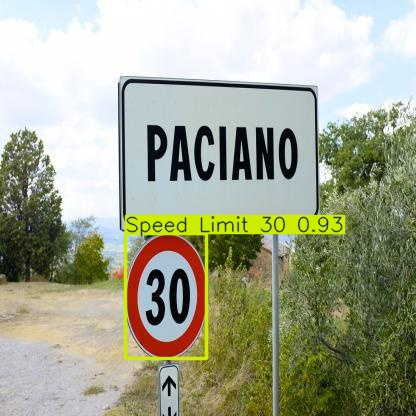

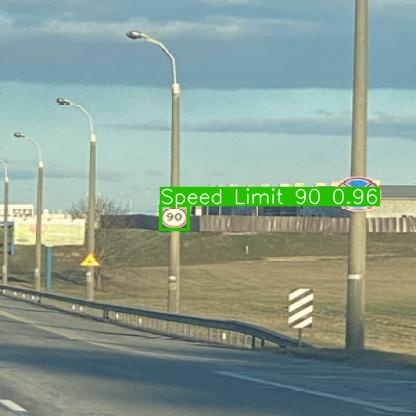

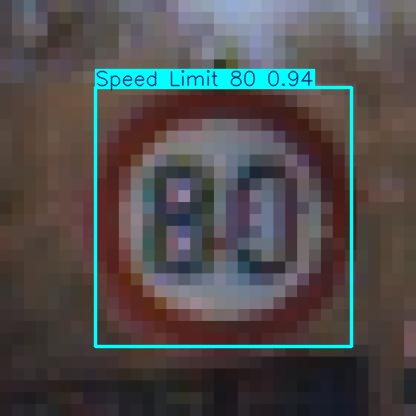

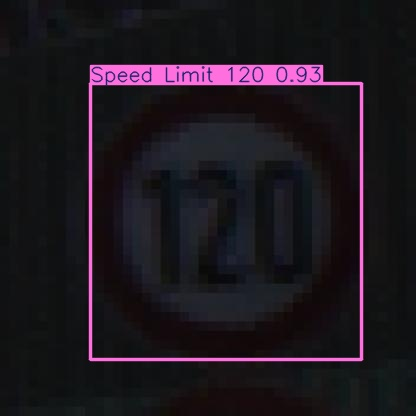

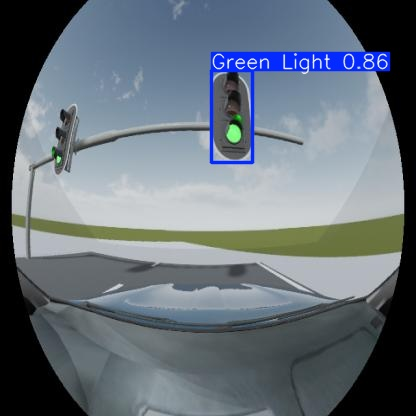

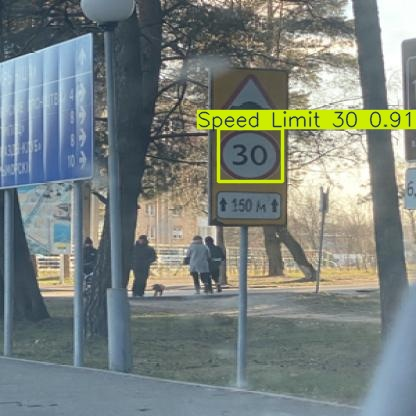

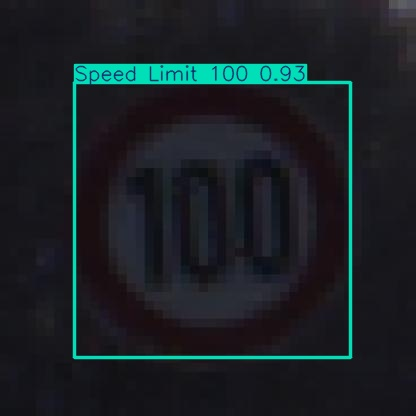

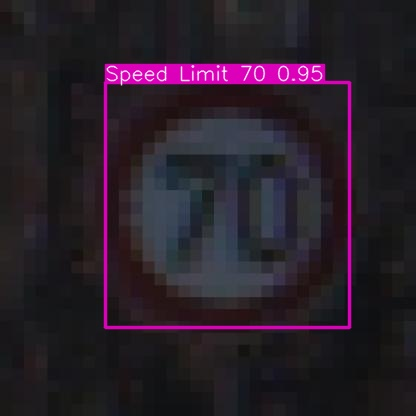

In [ ]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')

In [ ]:
# Create "my_model" folder to store model weights and train results
!mkdir /content/my_model
!cp drive/MyDrive/yolo_models_3/weights/best.pt /content/my_model/my_model.pt
!cp -r drive/MyDrive/yolo_models_3 /content/my_model

# Zip into "my_model.zip"
%cd my_model
!zip /content/my_model.zip my_model.pt
!zip -r /content/my_model.zip train
%cd /content

mkdir: cannot create directory ‘/content/my_model’: File exists
/content/my_model
  adding: my_model.pt (deflated 8%)
	zip warning: name not matched: train

zip error: Nothing to do! (try: zip -r /content/my_model.zip . -i train)
/content


In [ ]:
# This takes forever for some reason, you can also just download the model from the sidebar
from google.colab import files

files.download('/content/my_model.zip')